In [1]:
# 1. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Cài đặt thư viện facenet-pytorch
!pip install facenet-pytorch torchvision Pillow

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Khởi tạo mtcnn
### image_size = 160: Kích thước khuôn mặt sau khi bị cắt ra, mô hình facenet phía sau y/c là ảnh vuông kích thước 160x160 ==> set sẵn để mtcnn tự động resize cho khớp
### margin = 0: Khoảng lề cộng thêm xung quanh khuôn mặt sau khi cắt( ảnh cắt ra bám sát khuôn mặt, không lấy thêm tóc/ cổ/ bối cảnh xung quanh)
### min_face_resize = 20: Kích thước khuôn mặt nhỏ nhất(pixel) mà mtcnn cố gắng tìm kiếm. Ví dụ như set min_face càng nhỏ thì tìm đc người đứng càng xa, nhưng đánh đổi thời gian tính toán.
### ngưỡng = [0.6, 0.7, 0.7]:
#### Mạng 1(P-Net): Quét nhanh toàn bộ gương mặt. Thresh > 60% thì đi tiếp
#### Mạng 2(R Net) Tương tự với mức 0.7
#### Mangk 3(O-Net) Tương tự
### factor = 0.709: Con số tạo tháp ảnh. 0.709 là chuẩn tối ưu được công bố trong bài báo khoa học gốc mtcnn
### post_process = True: MTCNN Tự động chuẩn hóa các pixel ảnh đc cắt. Thay vì dùng dải màu từ 0-255, nó quy đổi về -1 -> 1 để tương thích facenet
# 2. Khởi tạo FaceNet
### Nvụ: Nhận output là 160x160 của mtcnn đưa qua mạng neuron sâu để biến thành 1 vector 512 chiều. Vector này đóng vai trò như căn cước của bức ảnh đó
### InceptionResNetV1: Inception + Resnet(quét nhiều đặc trưng cùng lúc + mạng phần dư)
### pretrained = vggface2: Dùng lại weight của mô hình có sẵn vggface2. Dùng pretrain để mô hình phân biệt khuôn mặt mà không cần học lại từ đầu
### eval(): Đặt mô hình pytorch vào trạng thái suy luận(Chỉ dự đoán)

In [2]:
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import os

# Kiểm tra xem có GPU không, nếu có sẽ chạy nhanh hơn rất nhiều
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Running on device: {device}')

# 1. Khởi tạo MTCNN:
# Tham số post_process=True sẽ chuẩn hóa ảnh (normalize) sau khi cắt để đưa vào FaceNet.
# image_size=160 là chuẩn đầu vào của FaceNet.
mtcnn = MTCNN(
    image_size=160, margin=0, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
    device=device
)

# 2. Khởi tạo FaceNet (InceptionResnetV1)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

Running on device: cpu


  0%|          | 0.00/107M [00:00<?, ?B/s]

In [3]:
# ĐỔI ĐƯỜNG DẪN NÀY THÀNH ĐƯỜNG DẪN THỰC TẾ TRÊN DRIVE CỦA BẠN
DATA_DIR = '/content/drive/MyDrive/Dataset Face Reg'

def process_and_save_embeddings(data_dir, save_path='data.pt'):
    # Đọc dữ liệu theo cấu trúc thư mục
    dataset = datasets.ImageFolder(data_dir)
    # Lưu lại mapping giữa ID và Tên thư mục (Tên người)
    dataset.idx_to_class = {i:c for c, i in dataset.class_to_idx.items()}

    # Dùng DataLoader để duyệt qua từng ảnh
    loader = DataLoader(dataset, collate_fn=lambda x: x[0])

    name_list = []
    embedding_list = []

    print("Bắt đầu xử lý ảnh...")
    for i, (img, idx) in enumerate(loader):
        # Phát hiện khuôn mặt bằng MTCNN
        # Trả về tensor khuôn mặt đã được crop/resize (nếu có) và xác suất
        face, prob = mtcnn(img, return_prob=True)

        # Nếu MTCNN tìm thấy khuôn mặt với độ tin cậy > 90%
        if face is not None and prob > 0.90:
            # FaceNet yêu cầu input là 1 batch, nên ta thêm 1 chiều bằng unsqueeze(0)
            emb = resnet(face.unsqueeze(0).to(device)) #Nhận tấm ảnh khuôn mặt đã cắt và biến nó thành một Vector 512 chiều (embedding).

            embedding_list.append(emb.detach().cpu())
            name_list.append(dataset.idx_to_class[idx])

        if (i+1) % 20 == 0:
            print(f"Đã xử lý {i+1} ảnh...")

    # Lưu toàn bộ embeddings và tên tương ứng vào file .pt
    embeddings = torch.cat(embedding_list)
    names = name_list
    torch.save({'embeddings': embeddings, 'names': names}, save_path)
    print(f"\nHoàn tất! Đã lưu trữ embeddings cho {len(names)} khuôn mặt hợp lệ vào {save_path}")

# Chạy hàm xử lý
process_and_save_embeddings(DATA_DIR, save_path='/content/drive/MyDrive/face_data.pt')

Bắt đầu xử lý ảnh...
Đã xử lý 20 ảnh...
Đã xử lý 40 ảnh...
Đã xử lý 60 ảnh...
Đã xử lý 80 ảnh...
Đã xử lý 100 ảnh...
Đã xử lý 120 ảnh...
Đã xử lý 140 ảnh...
Đã xử lý 160 ảnh...
Đã xử lý 180 ảnh...
Đã xử lý 200 ảnh...
Đã xử lý 220 ảnh...
Đã xử lý 240 ảnh...
Đã xử lý 260 ảnh...
Đã xử lý 280 ảnh...

Hoàn tất! Đã lưu trữ embeddings cho 276 khuôn mặt hợp lệ vào /content/drive/MyDrive/face_data.pt



BẢNG THỐNG KÊ KẾT QUẢ NHẬN DIỆN - ẢNH THỨ 12
+---------------+-------------------+-------------------+----------------+--------------+
| Thư mục gốc   | Người nhận diện   | Metric sử dụng    |   Điểm (Score) | Trạng thái   |
+===============+===================+===================+================+==============+
| Triết         | Triết             | Cosine Similarity |              1 | THÀNH CÔNG   |
+---------------+-------------------+-------------------+----------------+--------------+
| Triệu/Trieu   | Triệu             | Cosine Similarity |              1 | THÀNH CÔNG   |
+---------------+-------------------+-------------------+----------------+--------------+
| Trí           | Trí               | Cosine Similarity |              1 | THÀNH CÔNG   |
+---------------+-------------------+-------------------+----------------+--------------+
| Vi            | Vi                | Cosine Similarity |              1 | THÀNH CÔNG   |
+---------------+-------------------+------------

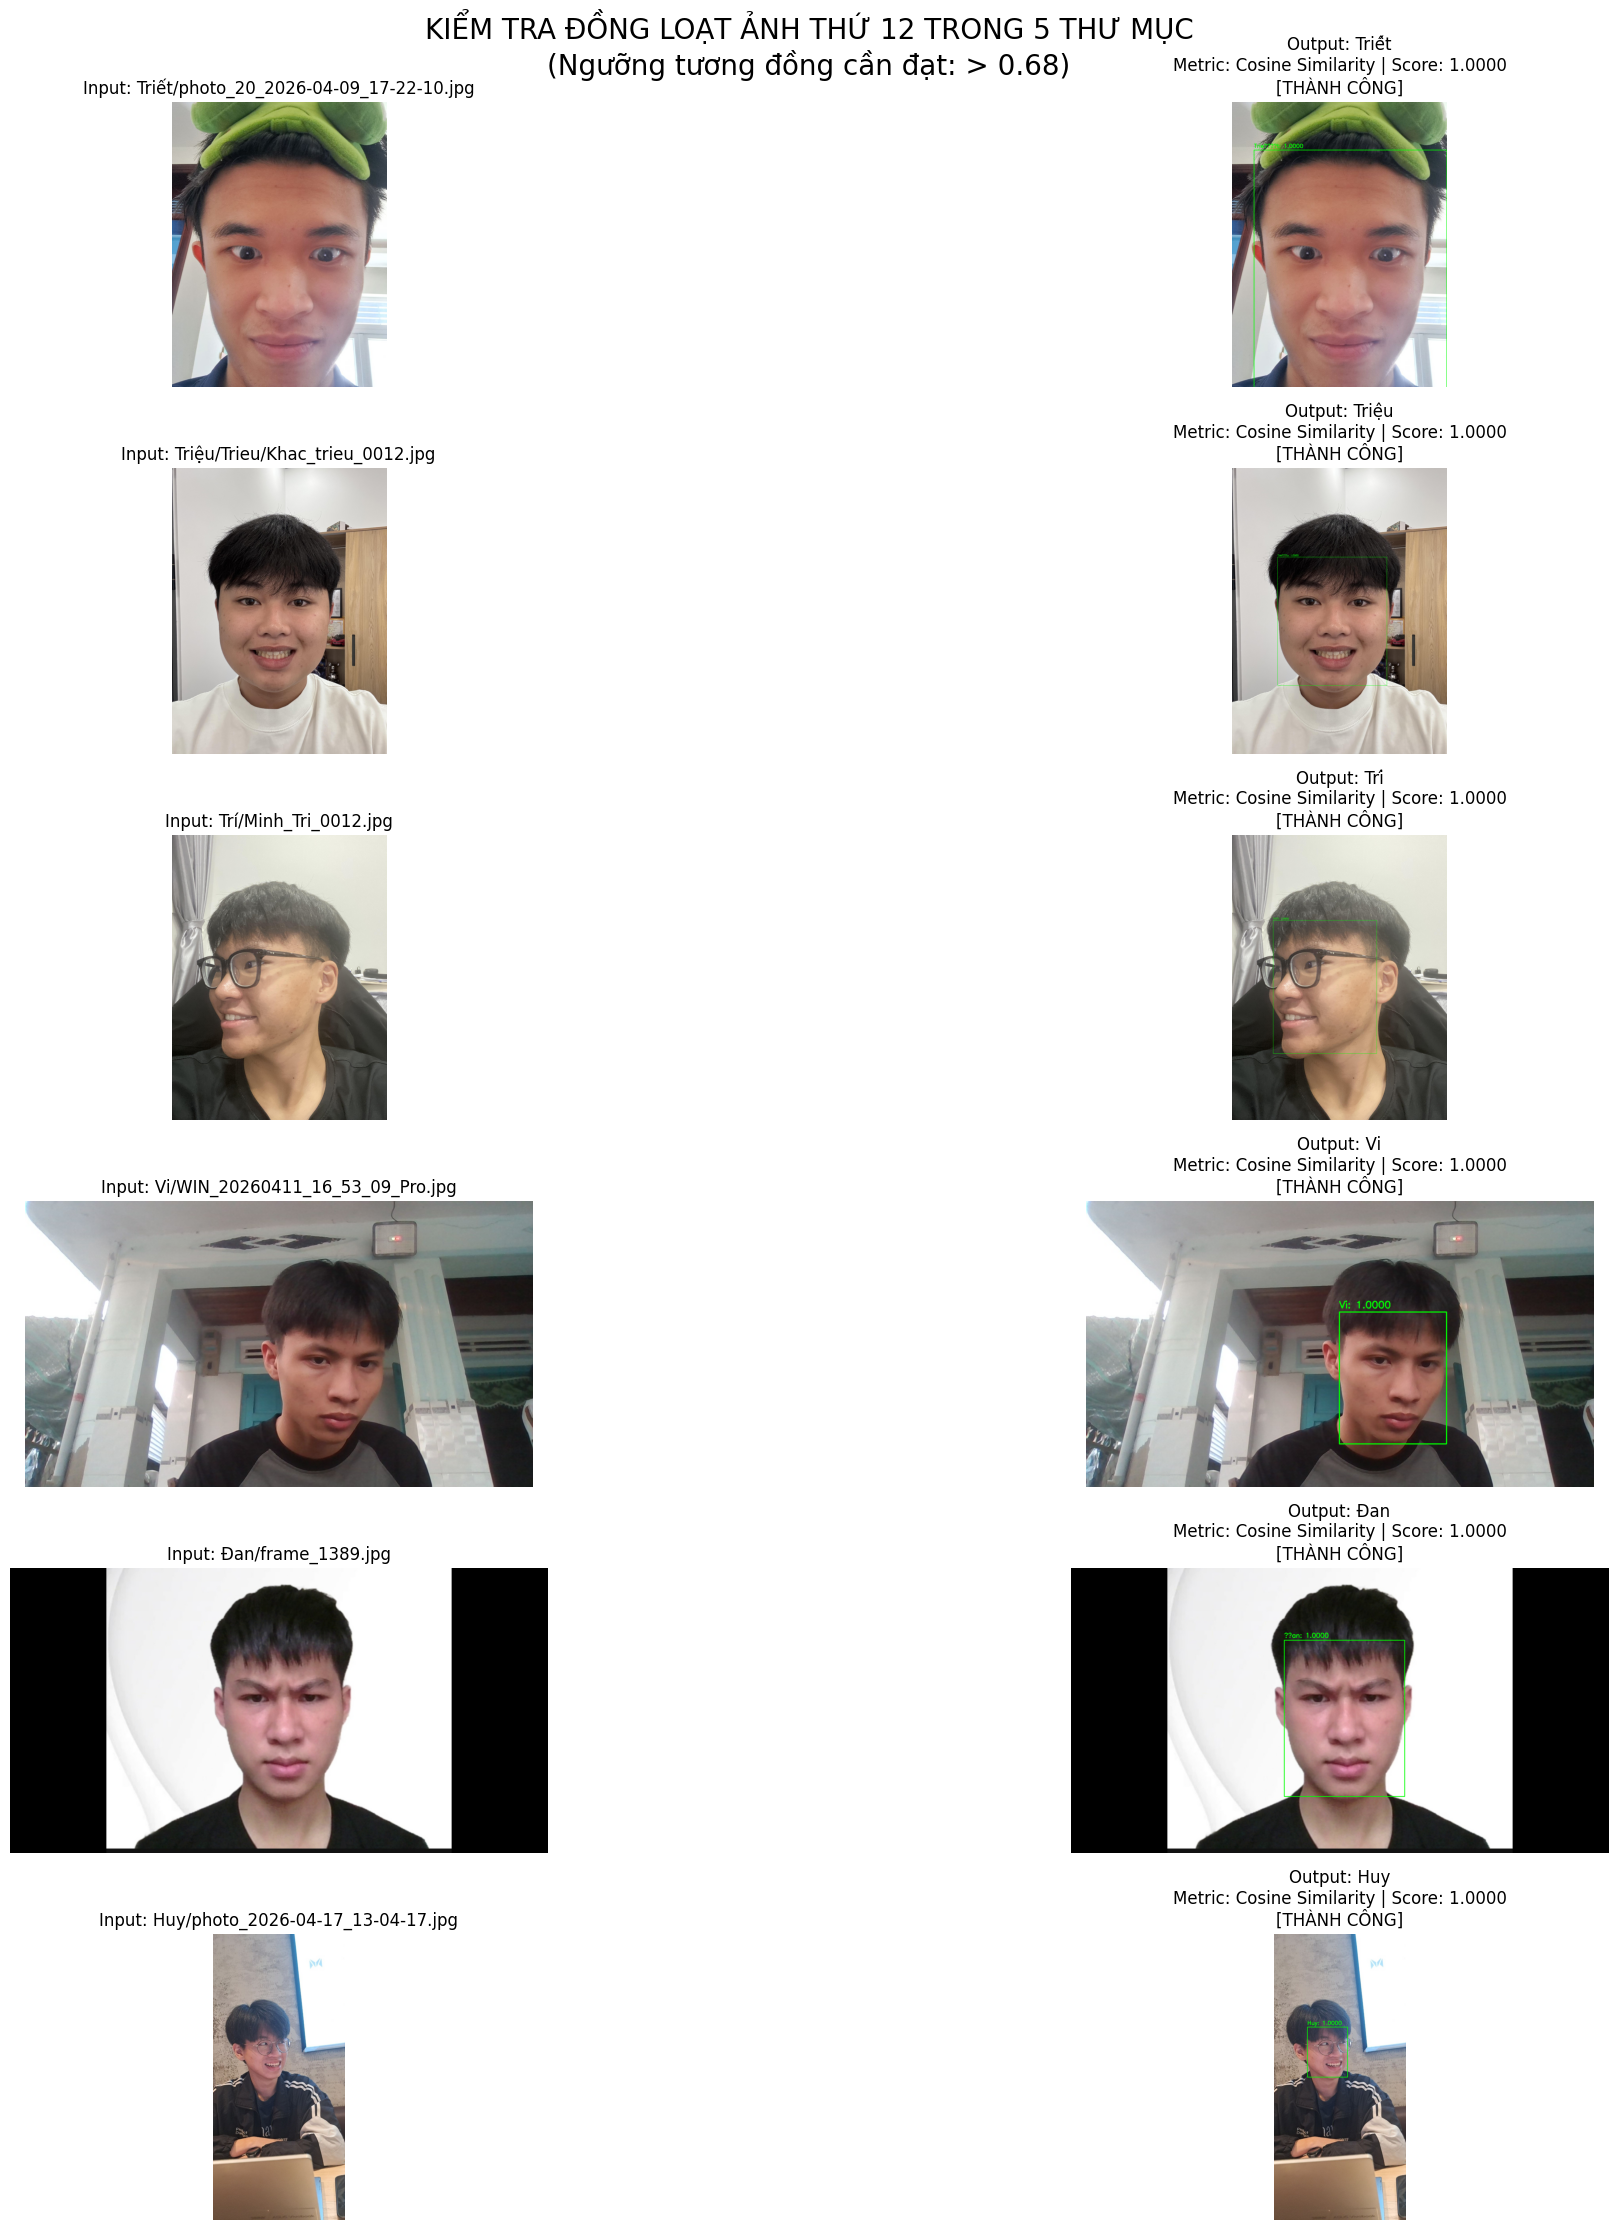

In [9]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image
import torch
from tabulate import tabulate # Import thêm thư viện kẻ bảng text

def test_five_images_at_once(i, base_dir='/content/drive/MyDrive/Dataset Face Reg', saved_data_path='/content/drive/MyDrive/face_data.pt', dist_threshold=0.8):
    folders = ['Triết', 'Triệu/Trieu', 'Trí', 'Vi', 'Đan','Huy']
    py_index = i - 1

    try:
        saved_data = torch.load(saved_data_path)
        saved_emb = saved_data['embeddings']
        saved_names = saved_data['names']
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file {saved_data_path}.")
        return

    sim_threshold = 1 - (dist_threshold ** 2) / 2

    fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(25, 25))
    fig.suptitle(f"KIỂM TRA ĐỒNG LOẠT ẢNH THỨ {i} TRONG 5 THƯ MỤC\n(Ngưỡng tương đồng cần đạt: > {sim_threshold:.2f})", fontsize=20, y=0.92)

    # Khởi tạo một list rỗng để hứng dữ liệu thay vì in luôn ra màn hình
    table_data = []

    for row_idx, folder_name in enumerate(folders):
        ax_in = axes[row_idx, 0]
        ax_out = axes[row_idx, 1]

        folder_path = os.path.join(base_dir, folder_name)

        if not os.path.exists(folder_path):
            ax_in.text(0.5, 0.5, f"Không tìm thấy thư mục:\n{folder_name}", ha='center', va='center')
            ax_in.axis('off')
            ax_out.axis('off')
            table_data.append([folder_name, "N/A", "N/A", "N/A", "THIẾU THƯ MỤC"])
            continue

        valid_exts = ('.jpg', '.jpeg', '.png')
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]
        images.sort()

        if py_index < 0 or py_index >= len(images):
            ax_in.text(0.5, 0.5, f"Thư mục {folder_name} không có ảnh thứ {i}", ha='center', va='center')
            ax_in.axis('off')
            ax_out.axis('off')
            table_data.append([folder_name, "N/A", "N/A", "N/A", "THIẾU ẢNH"])
            continue

        img_name = images[py_index]
        img_path = os.path.join(folder_path, img_name)

        img = Image.open(img_path).convert('RGB')

        ax_in.imshow(img)
        ax_in.set_title(f"Input: {folder_name}/{img_name}", fontsize=12)
        ax_in.axis('off')

        boxes, probs = mtcnn.detect(img)

        if boxes is not None:
            box = boxes[0]
            face = mtcnn(img)

            if face is not None:
                emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()

                dists = [[(emb - e).norm().item(), name] for e, name in zip(saved_emb, saved_names)]
                dists.sort(key=lambda x: x[0])
                min_dist, best_match = dists[0]

                metric_name = "Cosine Similarity"
                metric_score = 1 - (min_dist ** 2) / 2

                status_code = "THÀNH CÔNG" if metric_score > sim_threshold else "NGƯỜI LẠ"

                # Lưu từng dòng kết quả vào list
                table_data.append([folder_name, best_match, metric_name, f"{metric_score:.4f}", status_code])

                img_draw = np.array(img).copy()
                img_draw_bgr = cv2.cvtColor(img_draw, cv2.COLOR_RGB2BGR)
                l, t, r, b = box.astype(int)

                color = (0, 255, 0) if metric_score > sim_threshold else (0, 0, 255)

                cv2.rectangle(img_draw_bgr, (l, t), (r, b), color, 2)

                box_text = f"{best_match}: {metric_score:.4f}"
                cv2.putText(img_draw_bgr, box_text, (l, max(t-10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

                img_result_rgb = cv2.cvtColor(img_draw_bgr, cv2.COLOR_BGR2RGB)

                ax_out.imshow(img_result_rgb)

                title_text = (f"Output: {best_match}\n"
                              f"Metric: {metric_name} | Score: {metric_score:.4f}\n"
                              f"[{status_code}]")
                ax_out.set_title(title_text, fontsize=12)
                ax_out.axis('off')
            else:
                ax_out.text(0.5, 0.5, "MTCNN cắt ảnh lỗi", ha='center', va='center')
                ax_out.axis('off')
                table_data.append([folder_name, "N/A", "N/A", "N/A", "LỖI CẮT ẢNH"])
        else:
            ax_out.imshow(img)
            ax_out.set_title("Cảnh báo: Không tìm thấy khuôn mặt", color='red')
            ax_out.axis('off')
            table_data.append([folder_name, "N/A", "N/A", "N/A", "KHÔNG THẤY MẶT"])

    # --- IN BẢNG TEXT TRỰC QUAN BẰNG TABULATE ---
    print(f"\nBẢNG THỐNG KÊ KẾT QUẢ NHẬN DIỆN - ẢNH THỨ {i}")
    headers = ["Thư mục gốc", "Người nhận diện", "Metric sử dụng", "Điểm (Score)", "Trạng thái"]

    # Sử dụng tablefmt='grid' để kẻ khung vuông vức
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print("\n") # Dấu cách trước khi hiện hình

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Test
test_five_images_at_once(i=13, dist_threshold=0.8)

📊 Kết quả phân tích:
- Người giống nhất : Huy
- Độ tương đồng    : 0.7242
- Ngưỡng yêu cầu   : > 0.6800
- Trạng thái       : THÀNH CÔNG


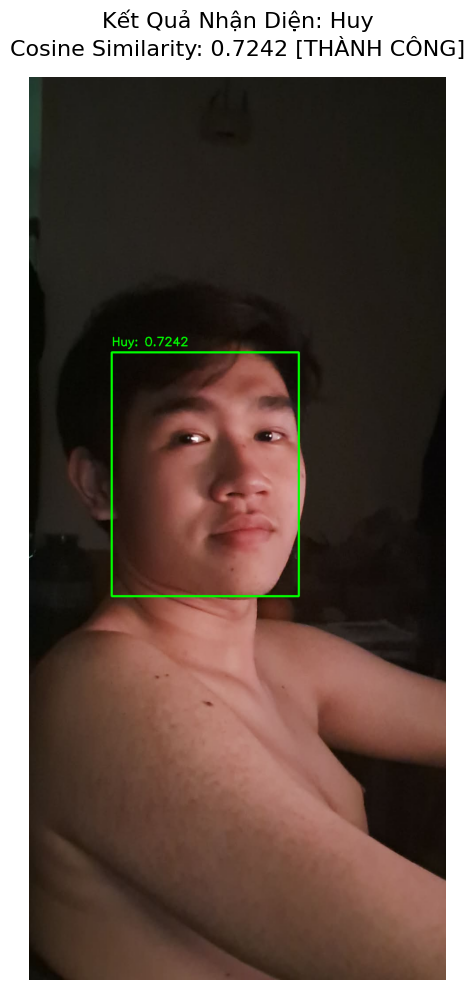

In [22]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def recognize_single_image(image_path, db_path='/content/drive/MyDrive/face_data.pt', dist_threshold=0.8):
    """
    Hàm nhận diện khuôn mặt cho MỘT bức ảnh đầu vào bất kỳ.
    """
    # 1. Tải Database của nhóm
    try:
        saved_data = torch.load(db_path)
        saved_emb = saved_data['embeddings']
        saved_names = saved_data['names']
    except FileNotFoundError:
        print(f"❌ Lỗi: Không tìm thấy file Database tại {db_path}.")
        return

    # Tính toán ngưỡng Cosine Similarity
    sim_threshold = 1 - (dist_threshold ** 2) / 2

    # 2. Đọc ảnh đầu vào
    if not os.path.exists(image_path):
        print(f"❌ Lỗi: Không tìm thấy ảnh tại {image_path}. Hãy kiểm tra lại đường dẫn!")
        return

    img = Image.open(image_path).convert('RGB')

    # Khởi tạo khung vẽ
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.axis('off')

    # 3. Dò tìm khuôn mặt bằng MTCNN
    boxes, probs = mtcnn.detect(img)

    if boxes is not None:
        # Lấy khuôn mặt rõ nhất (box đầu tiên)
        box = boxes[0]
        face = mtcnn(img)

        if face is not None:
            # Trích xuất vector đặc trưng
            emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()

            # So sánh với toàn bộ database để tìm người giống nhất
            dists = [[(emb - e).norm().item(), name] for e, name in zip(saved_emb, saved_names)]
            dists.sort(key=lambda x: x[0])
            min_dist, best_match = dists[0]

            # Tính điểm
            metric_score = 1 - (min_dist ** 2) / 2
            is_match = metric_score > sim_threshold

            status_code = "THÀNH CÔNG" if is_match else "NGƯỜI LẠ"
            color = (0, 255, 0) if is_match else (0, 0, 255) # Xanh nếu quen, Đỏ nếu lạ

            # Vẽ Box và Text lên ảnh
            img_draw = np.array(img).copy()
            img_draw_bgr = cv2.cvtColor(img_draw, cv2.COLOR_RGB2BGR)
            l, t, r, b = box.astype(int)

            cv2.rectangle(img_draw_bgr, (l, t), (r, b), color, 3)
            box_text = f"{best_match}: {metric_score:.4f}"
            cv2.putText(img_draw_bgr, box_text, (l, max(t-15, 25)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            # Hiển thị kết quả
            img_result_rgb = cv2.cvtColor(img_draw_bgr, cv2.COLOR_BGR2RGB)
            ax.imshow(img_result_rgb)
            ax.set_title(f"Kết Quả Nhận Diện: {best_match}\nCosine Similarity: {metric_score:.4f} [{status_code}]", fontsize=16, pad=15)

            print(f"📊 Kết quả phân tích:")
            print(f"- Người giống nhất : {best_match}")
            print(f"- Độ tương đồng    : {metric_score:.4f}")
            print(f"- Ngưỡng yêu cầu   : > {sim_threshold:.4f}")
            print(f"- Trạng thái       : {status_code}")

        else:
            ax.imshow(img)
            ax.set_title("❌ Lỗi: MTCNN phát hiện có mặt nhưng không cắt được (ảnh quá mờ/nhỏ)", color='red', fontsize=14)
    else:
        ax.imshow(img)
        ax.set_title("⚠️ Cảnh báo: AI không tìm thấy khuôn mặt nào trong bức ảnh này!", color='red', fontsize=14)

    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH SỬ DỤNG
# ==========================================
# Bạn tải 1 bức ảnh mới lên Drive (hoặc upload thẳng lên Colab), sau đó dán đường dẫn vào đây:
anh_can_test = '/content/drive/MyDrive/280f5d1d-edf3-4819-be1a-41987f09d52d.jpg'

# Chạy hàm nhận diện
recognize_single_image(image_path=anh_can_test, dist_threshold=0.8)

👉 Nhập đường dẫn hoặc Link ảnh của bạn vào đây: https://baotiengdan.com/wp-content/uploads/2020/07/0-36.jpg

 KẾT QUẢ PHÂN TÍCH:
- Người được nhận diện : KHÔNG XÁC ĐỊNH (Người lạ)
- (Nét giống nhất với    : Vi nhưng bị từ chối do điểm quá thấp)
- Điểm tương đồng      : 0.2619
- Trạng thái           : NGƯỜI LẠ


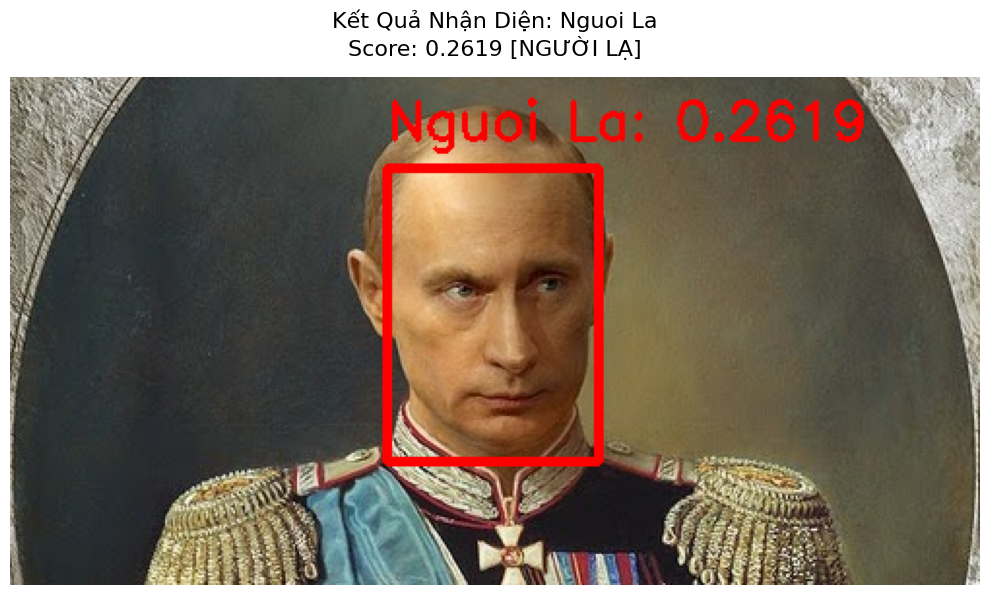

In [25]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

def recognize_single_image(image_input, db_path='/content/drive/MyDrive/face_data.pt', dist_threshold=0.8):
    # 1. Tải Database
    try:
        saved_data = torch.load(db_path)
        saved_emb = saved_data['embeddings']
        saved_names = saved_data['names']
    except FileNotFoundError:
        print(f"❌ Lỗi: Không tìm thấy file Database tại {db_path}.")
        return

    sim_threshold = 1 - (dist_threshold ** 2) / 2

    # 2. Đọc ảnh đầu vào
    try:
        if image_input.startswith('http://') or image_input.startswith('https://'):
            response = requests.get(image_input)
            img = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            if not os.path.exists(image_input):
                print(f"❌ Lỗi: Không tìm thấy ảnh tại {image_input}. Hãy kiểm tra lại đường dẫn!")
                return
            img = Image.open(image_input).convert('RGB')
    except Exception as e:
        print(f" Lỗi khi đọc ảnh: {e}")
        return

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.axis('off')

    # 3. Dò tìm khuôn mặt
    boxes, probs = mtcnn.detect(img)

    if boxes is not None:
        box = boxes[0]
        face = mtcnn(img)

        if face is not None:
            emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()
            dists = [[(emb - e).norm().item(), name] for e, name in zip(saved_emb, saved_names)]
            dists.sort(key=lambda x: x[0])
            min_dist, best_match = dists[0]

            metric_score = 1 - (min_dist ** 2) / 2
            is_match = metric_score > sim_threshold

            # ========================================================
            # LOGIC HIỂN THỊ MỚI: Ẩn hoàn toàn tên nếu là người lạ
            # ========================================================
            if is_match:
                display_name = best_match # Nếu quen thì hiện tên thật
                status_code = "THÀNH CÔNG"
                color = (0, 255, 0)
            else:
                display_name = "Nguoi La" # Nếu lạ thì ghi đè tên thành chữ "Nguoi La"
                status_code = "NGƯỜI LẠ"
                color = (0, 0, 255)

            img_draw = np.array(img).copy()
            img_draw_bgr = cv2.cvtColor(img_draw, cv2.COLOR_RGB2BGR)
            l, t, r, b = box.astype(int)

            cv2.rectangle(img_draw_bgr, (l, t), (r, b), color, 3)

            # In Tên đã được lọc + Score lên ảnh
            box_text = f"{display_name}: {metric_score:.4f}"
            cv2.putText(img_draw_bgr, box_text, (l, max(t-15, 25)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            img_result_rgb = cv2.cvtColor(img_draw_bgr, cv2.COLOR_BGR2RGB)
            ax.imshow(img_result_rgb)
            ax.set_title(f"Kết Quả Nhận Diện: {display_name}\nScore: {metric_score:.4f} [{status_code}]", fontsize=16, pad=15)

            # Console không in ra best_match nếu là người lạ nữa
            print(f"\n KẾT QUẢ PHÂN TÍCH:")
            if is_match:
                print(f"- Người được nhận diện : {display_name}")
            else:
                print(f"- Người được nhận diện : KHÔNG XÁC ĐỊNH (Người lạ)")
                print(f"- (Nét giống nhất với    : {best_match} nhưng bị từ chối do điểm quá thấp)") # Chỉ in log nhỏ để bạn biết mô hình đang hoạt động đúng

            print(f"- Điểm tương đồng      : {metric_score:.4f}")
            print(f"- Trạng thái           : {status_code}")

        else:
            ax.imshow(img)
            ax.set_title("❌ Lỗi: Có mặt nhưng không cắt được", color='red')
    else:
        ax.imshow(img)
        ax.set_title("⚠️ AI không tìm thấy khuôn mặt nào!", color='red')

    plt.tight_layout()
    plt.show()

# ==========================================
# GIAO DIỆN NHẬP LIỆU
# ==========================================
user_input = input("👉 Nhập đường dẫn hoặc Link ảnh của bạn vào đây: ").strip()

if user_input:
    recognize_single_image(
        image_input=user_input,
        db_path='/content/drive/MyDrive/face_data.pt', # Đảm bảo file database trỏ đúng
        dist_threshold=0.8
    )
else:
    print("⚠️ Bạn chưa nhập đường dẫn nào!")

#Nhận diện người trong ảnh (pp2) Dùng 5-10 ảnh nạp vào huy.pt

In [5]:
import os
import torch
from PIL import Image

def create_robust_database(folder_path, save_path, name="Huy"):
    embeddings = []
    valid_exts = ('.jpg', '.jpeg', '.png')

    images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]
    print(f"Tìm thấy {len(images)} ảnh trong thư mục {name}. Đang trích xuất...")

    for img_name in images:
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path).convert('RGB')
        face, prob = mtcnn(img, return_prob=True)

        if face is not None and prob > 0.9:
            emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()
            embeddings.append(emb)
            print(f"  + Trích xuất thành công: {img_name}")
        else:
            print(f"  - Bỏ qua {img_name} (Không thấy rõ mặt)")

    if embeddings:
        # Gộp tất cả các vector lại và chia trung bình (Mean)
        avg_emb = torch.stack(embeddings).mean(dim=0)

        # Chuẩn hóa lại vector (L2 Normalization) để phép tính Cosine luôn chuẩn xác
        avg_emb = avg_emb / avg_emb.norm(p=2, dim=1, keepdim=True)

        torch.save({'embeddings': avg_emb, 'names': [name]}, save_path)
        print(f"\n✅ THÀNH CÔNG! Đã gộp {len(embeddings)} ảnh thành 1 Vector siêu chuẩn cho {name}.")
    else:
        print("❌ Lỗi: Không có ảnh nào trích xuất được.")

# Cách dùng: Đảm bảo thư mục của Huy có khoảng 5-10 tấm ảnh đa dạng góc độ
huy_folder = '/content/drive/MyDrive/Dataset Face Reg/Huy'
db_path = '/content/drive/MyDrive/Colab Notebooks/huy_db.pt'

create_robust_database(huy_folder, db_path, name="Huy")

Tìm thấy 38 ảnh trong thư mục Huy. Đang trích xuất...
  + Trích xuất thành công: photo_2026-04-17_13-04-03.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-04.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-05.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-06.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-08.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-10.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-11.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-12.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-14.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-15.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-16.jpg
  + Trích xuất thành công: photo_2026-04-17_13-04-17.jpg
  - Bỏ qua photo_2026-04-17_13-04-18.jpg (Không thấy rõ mặt)
  - Bỏ qua photo_2026-04-17_13-04-19.jpg (Không thấy rõ mặt)
  - Bỏ qua photo_2026-04-17_13-04-20.jpg (Không thấy rõ mặt)
  + Trích xuất thành công: photo_2026-04-17_13-04-21.jpg
  + Trích xuất thành c

In [6]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import time

# ========================================================
# CÁC ĐƯỜNG DẪN CỦA BẠN (Đã thiết lập sẵn)
# ========================================================
input_video_path = '/content/drive/MyDrive/Colab Notebooks/96a40917-3216-4741-92c3-deb474cec9bf.mp4'
output_video_path = '/content/drive/MyDrive/Colab Notebooks/KetQua_Huy.mp4'
db_path = '/content/drive/MyDrive/Colab Notebooks/huy_db.pt' # Trỏ vào cái db siêu chuẩn bạn đã tạo

# ========================================================
# BƯỚC 2: ĐỌC VÀ NHẬN DIỆN VIDEO TỪ DRIVE (Bỏ luôn Bước 1)
# ========================================================
print("\n--- BẮT ĐẦU PHÂN TÍCH VIDEO ---")
dist_threshold = 0.8
process_every_n_frames = 2 # Xử lý 1, bỏ qua 1 để tăng tốc

if os.path.exists(db_path):
    # Lấy "Vector siêu chuẩn" lên
    saved_data = torch.load(db_path)
    saved_emb = saved_data['embeddings']

    # Chuyển đổi ngưỡng sang Cosine Similarity
    sim_threshold = 1 - (dist_threshold ** 2) / 2

    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print("❌ Lỗi: Không thể mở video gốc. File có thể bị lỗi hoặc sai đường dẫn.")
    else:
        width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        out = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
        start_time = time.time()
        frame_count = 0
        last_box, last_text, last_color = None, None, None

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            frame_count += 1

            if frame_count % process_every_n_frames == 1 or process_every_n_frames == 1:
                img_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                boxes, _ = mtcnn.detect(img_pil)

                if boxes is not None:
                    box = boxes[0]
                    face = mtcnn(img_pil)
                    if face is not None:
                        emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()

                        # So sánh vector (Vẫn logic cũ, nhưng giờ saved_emb[0] đã là vector siêu chuẩn)
                        min_dist = (emb - saved_emb[0]).norm().item()
                        score = 1 - (min_dist ** 2) / 2
                        is_match = score > sim_threshold

                        last_box = box.astype(int)
                        last_text = f"Huy: {score:.2f}" if is_match else f"Nguoi La: {score:.2f}"
                        last_color = (0, 255, 0) if is_match else (0, 0, 255)
                    else: last_box = None
                else: last_box = None

            if last_box is not None:
                l, t, r, b = last_box
                cv2.rectangle(frame, (l, t), (r, b), last_color, 2)
                cv2.putText(frame, last_text, (l, max(t-10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, last_color, 2)

            out.write(frame)
            if frame_count % 30 == 0:
                print(f" Đang phân tích AI: Đã quét {frame_count}/{total_frames} frames... ({(time.time() - start_time):.1f}s)")

        cap.release()
        out.release()
        print(f"\n🎉 HOÀN TẤT! Video kết quả của Huy đã được lưu tại: {output_video_path}")
else:
    print(f"❌ Lỗi: Không tìm thấy Database tại {db_path}. Vui lòng chạy lại code tạo Database bằng nhiều ảnh!")


--- BẮT ĐẦU PHÂN TÍCH VIDEO ---
 Đang phân tích AI: Đã quét 30/682 frames... (14.2s)
 Đang phân tích AI: Đã quét 60/682 frames... (21.1s)
 Đang phân tích AI: Đã quét 90/682 frames... (34.4s)
 Đang phân tích AI: Đã quét 120/682 frames... (50.6s)
 Đang phân tích AI: Đã quét 150/682 frames... (66.8s)
 Đang phân tích AI: Đã quét 180/682 frames... (83.6s)
 Đang phân tích AI: Đã quét 210/682 frames... (100.1s)
 Đang phân tích AI: Đã quét 240/682 frames... (115.1s)
 Đang phân tích AI: Đã quét 270/682 frames... (129.9s)
 Đang phân tích AI: Đã quét 300/682 frames... (146.5s)
 Đang phân tích AI: Đã quét 330/682 frames... (162.5s)
 Đang phân tích AI: Đã quét 360/682 frames... (177.5s)
 Đang phân tích AI: Đã quét 390/682 frames... (192.0s)
 Đang phân tích AI: Đã quét 420/682 frames... (205.8s)
 Đang phân tích AI: Đã quét 450/682 frames... (219.6s)
 Đang phân tích AI: Đã quét 480/682 frames... (235.7s)
 Đang phân tích AI: Đã quét 510/682 frames... (255.5s)
 Đang phân tích AI: Đã quét 540/682 frame

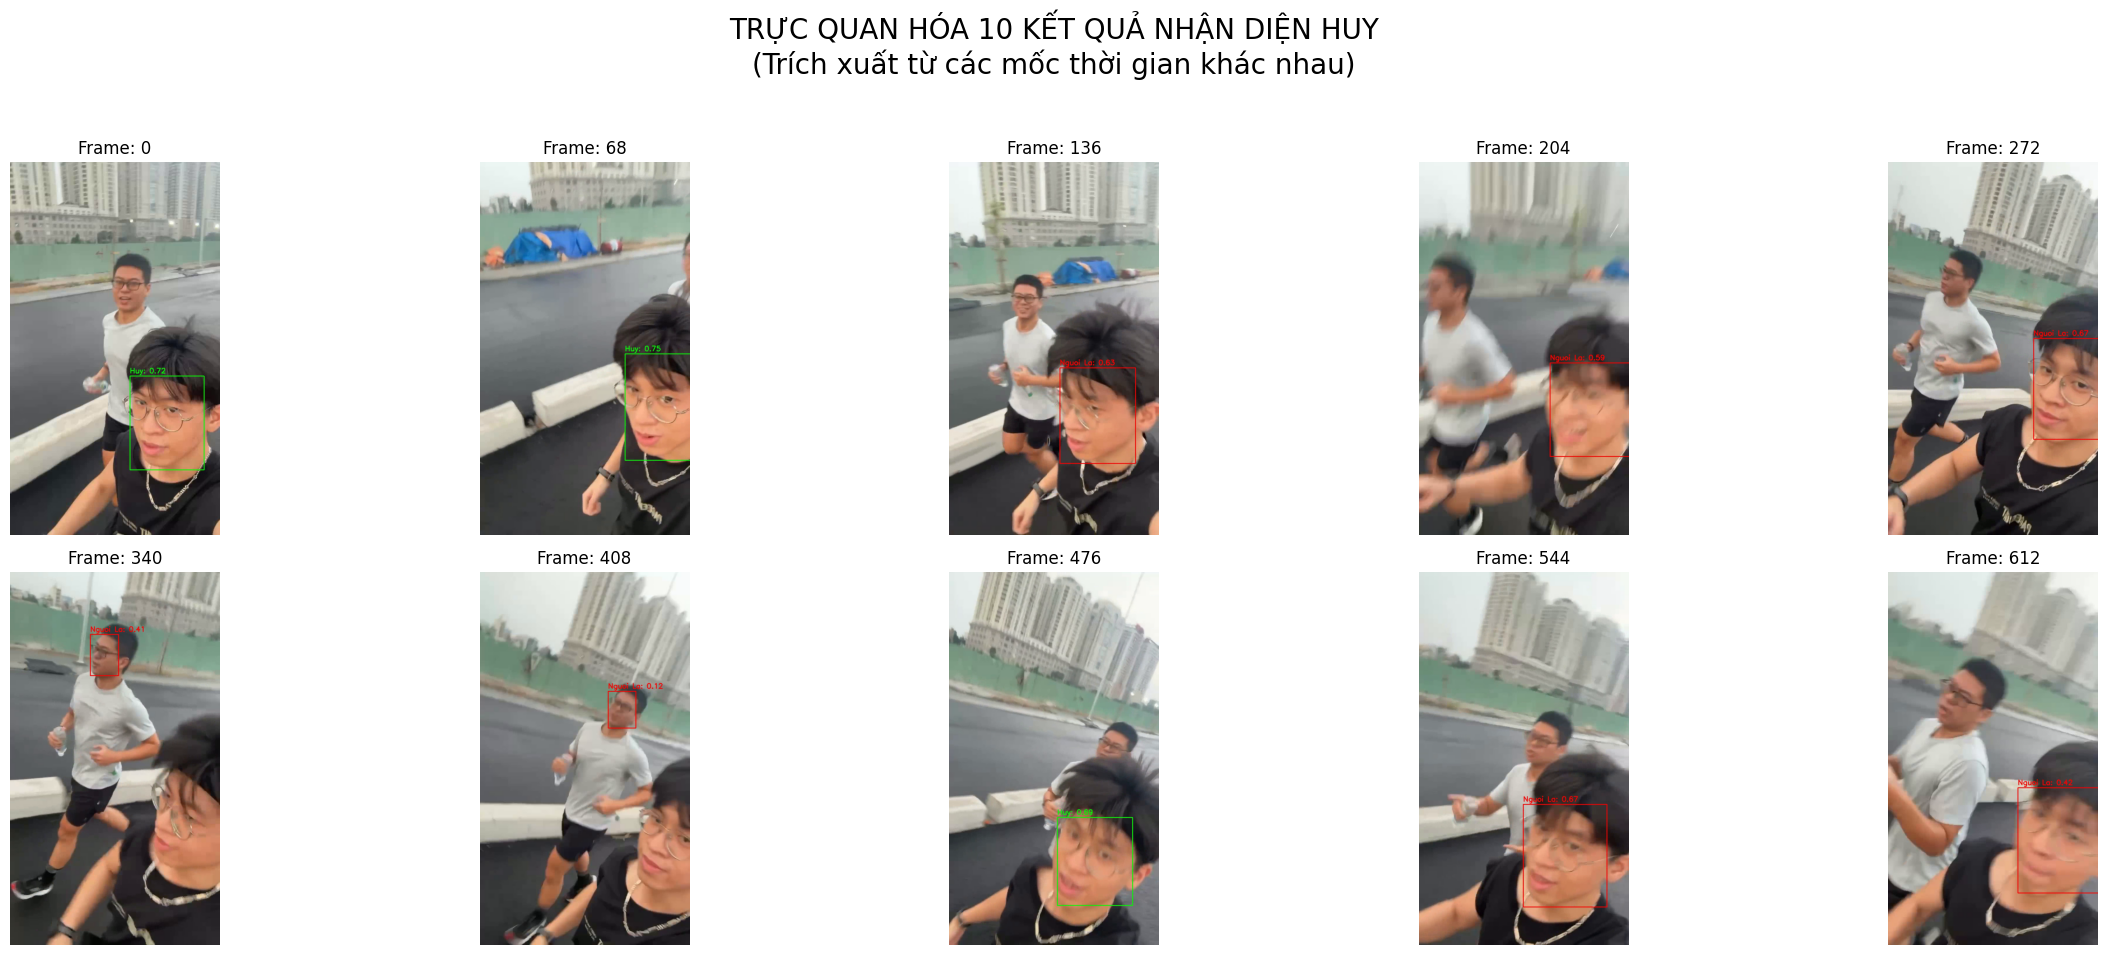

In [7]:
import cv2
import matplotlib.pyplot as plt

def visualize_10_results(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Lỗi: Không tìm thấy video. Kiểm tra lại đường dẫn!")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Chia video thành 10 đoạn bằng nhau
    num_samples = 10
    step = total_frames // num_samples
    sample_frames = [i * step for i in range(num_samples)]

    # Tạo lưới 2 hàng x 5 cột
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    fig.suptitle(f"TRỰC QUAN HÓA 10 KẾT QUẢ NHẬN DIỆN HUY\n(Trích xuất từ các mốc thời gian khác nhau)", fontsize=20)
    axes = axes.flatten()

    for idx, target_frame in enumerate(sample_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()

        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(frame_rgb)
            axes[idx].set_title(f"Frame: {target_frame}", fontsize=12)
            axes[idx].axis('off')
        else:
            axes[idx].axis('off')

    cap.release()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Đường dẫn video Huy vừa xử lý xong
video_huy = '/content/drive/MyDrive/Colab Notebooks/KetQua_Huy.mp4'
visualize_10_results(video_huy)